# Neural Style Transfer Matrix Optimizer

Neural Style Transfer (NST) synthesizes images combining the semantic structure of a **Content** image with the artistic textures of a **Style** image. This optimization framework minimizes content loss (MSE between feature maps) and style loss (MSE between Gram matrices of feature maps). This notebook implements a self-contained NST simulation in PyTorch optimizing a 32x32 target matrix over 60 epochs and visualizes results.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Define 32x32 Content and Style matrices
# Content: vertical block
content_img = np.zeros((32, 32))
content_img[8:24, 12:20] = 1.0

# Style: diagonal stripes
style_img = np.zeros((32, 32))
for i in range(32):
    for j in range(32):
        if (i + j) % 6 < 2:
            style_img[i, j] = 1.0

# Convert to tensors: shape [1, 1, 32, 32]
content_t = torch.FloatTensor(content_img).unsqueeze(0).unsqueeze(0)
style_t = torch.FloatTensor(style_img).unsqueeze(0).unsqueeze(0)

# Initialize Target image as random noise: learnable parameter
target_t = nn.Parameter(torch.rand(1, 1, 32, 32))

print("Content Tensor Shape:", content_t.shape)
print("Style Tensor Shape:  ", style_t.shape)



Content Tensor Shape: torch.Size([1, 1, 32, 32])
Style Tensor Shape:   torch.Size([1, 1, 32, 32])


## Feature Extraction Filters & Gram Matrix

We define simple convolution filters (extracting edge/texture features) and implement Gram Matrix calculations representing styles.



In [2]:
# Simple 2D feature extraction filter (horizontal and vertical edge detectors)
filters = torch.FloatTensor([
    [[[ 1,  2,  1], [ 0,  0,  0], [-1, -2, -1]]], # Horizontal
    [[[ 1,  0, -1], [ 2,  0, -2], [ 1,  0, -1]]]  # Vertical
])

def extract_features(x):
    # Apply conv2d with edge filters
    return nn.functional.conv2d(x, filters, padding=1)

def gram_matrix(x):
    b, c, h, w = x.size()
    features = x.view(b, c, h * w)
    # Batch matrix multiplication: features * features^T
    gram = torch.bmm(features, features.transpose(1, 2))
    return gram / (c * h * w)

# Calculate target content and style representations
content_features = extract_features(content_t).detach()
style_gram = gram_matrix(extract_features(style_t)).detach()



## Neural Optimization Loop

We optimize target pixel parameters for 60 epochs using Adam, balancing content reconstruction and style texture Gram matrices matching.



In [3]:
optimizer = optim.Adam([target_t], lr=0.08)
losses = []

# Style weight multiplier (10^3)
style_weight = 1000.0

for epoch in range(1, 61):
    target_features = extract_features(target_t)
    
    # 1. Content Loss
    loss_c = nn.functional.mse_loss(target_features, content_features)
    
    # 2. Style Loss
    target_gram = gram_matrix(target_features)
    loss_s = nn.functional.mse_loss(target_gram, style_gram)
    
    # Joint Loss
    total_loss = loss_c + style_weight * loss_s
    
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    # Clamp target values to keep pixels between 0 and 1
    with torch.no_grad():
        target_t.clamp_(0.0, 1.0)
        
    losses.append(total_loss.item())
    
    if epoch % 15 == 0:
        print(f"Epoch {epoch:2d}/60 | Joint NST Loss: {total_loss.item():.4f} (Content: {loss_c.item():.4f}, Style: {loss_s.item():.4f})")



Epoch 15/60 | Joint NST Loss: 371.3288 (Content: 5.7491, Style: 0.3656)
Epoch 30/60 | Joint NST Loss: 145.2193 (Content: 5.6842, Style: 0.1395)
Epoch 45/60 | Joint NST Loss: 79.2350 (Content: 5.6849, Style: 0.0736)
Epoch 60/60 | Joint NST Loss: 48.0924 (Content: 5.6283, Style: 0.0425)


## Content, Style, and Generated Target Visualization

Using a 1x3 Matplotlib subplot grid, we display the structural Content target, the striped Style texture, and the optimized generated target image.



<cell>:20: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



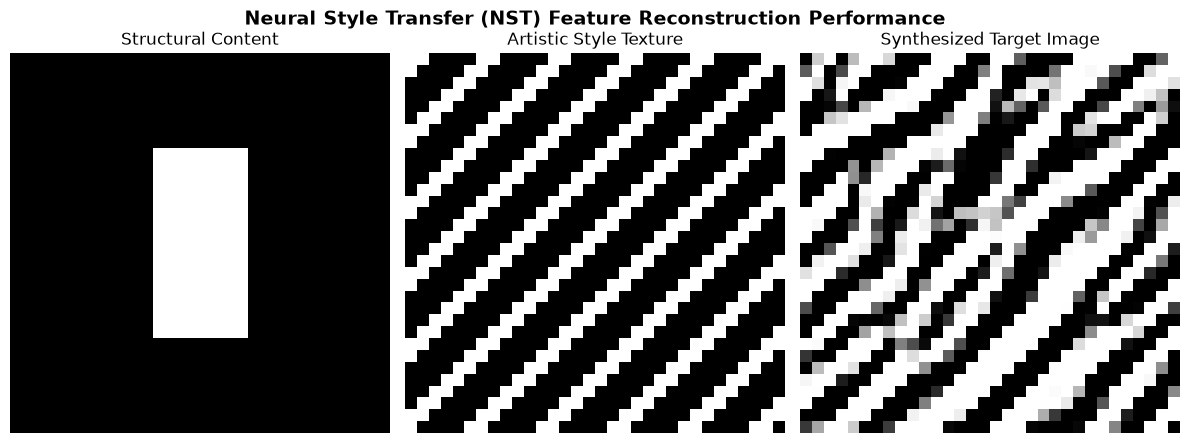

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))

axes[0].imshow(content_img, cmap='gray')
axes[0].set_title('Structural Content')
axes[0].axis('off')

axes[1].imshow(style_img, cmap='gray')
axes[1].set_title('Artistic Style Texture')
axes[1].axis('off')

with torch.no_grad():
    generated_img = target_t.squeeze(0).squeeze(0).numpy()
    
axes[2].imshow(generated_img, cmap='gray')
axes[2].set_title('Synthesized Target Image')
axes[2].axis('off')

plt.suptitle('Neural Style Transfer (NST) Feature Reconstruction Performance', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
